# Feature Selection

### 1. Import required libraries and Load the Dataset

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.feature_selection import RFE, chi2, SelectKBest
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import files
uploaded = files.upload()

Saving heart_disease_pca_dataset.csv to heart_disease_pca_dataset.csv


In [3]:
df = pd.read_csv('heart_disease_pca_dataset.csv')

In [4]:
X = df.drop('HeartDisease', axis=1)   # Features
y = df['HeartDisease']                # Target

### 2. Feature Importance (Random Forest / XGBoost)

* Random Forest Feature Importance


In [5]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

rf_importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

* Plot RF Feature Importance

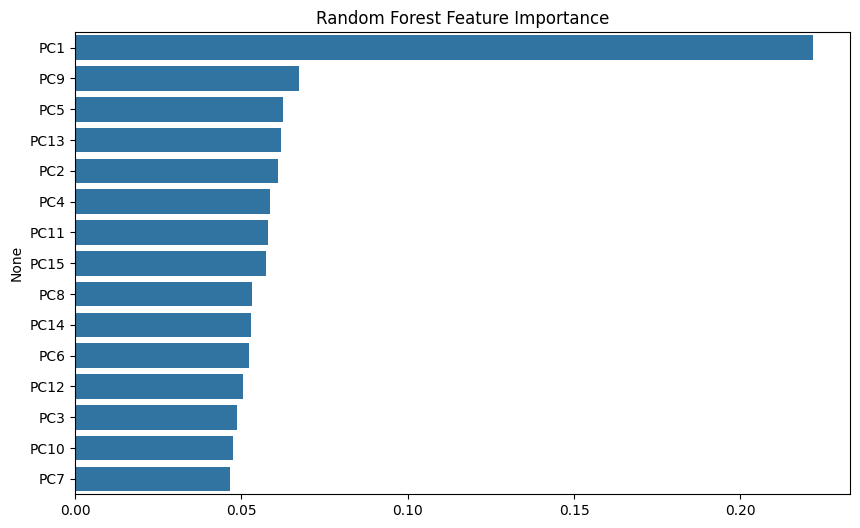

In [6]:
plt.figure(figsize=(10,6))
sns.barplot(x=rf_importances.values, y=rf_importances.index)
plt.title("Random Forest Feature Importance")
plt.show()

* XGBoost Feature Importance

In [8]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X, y)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [17:43:24] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

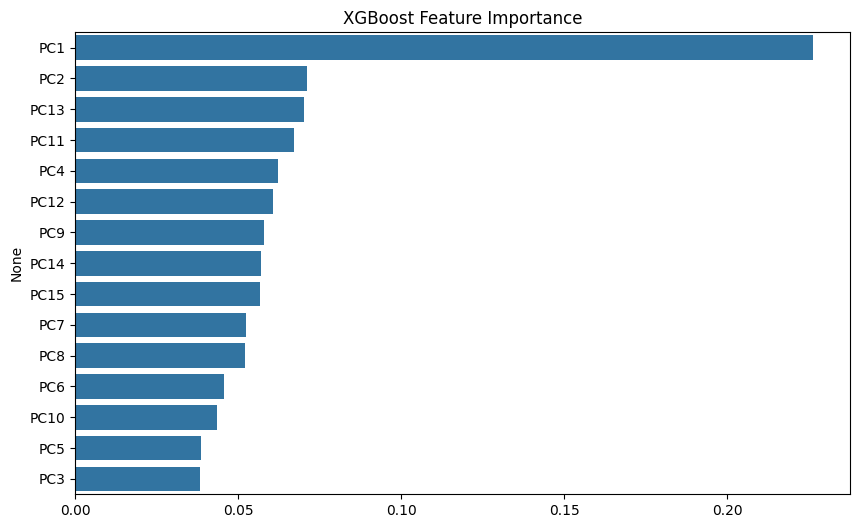

In [10]:
xgb_importances = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=xgb_importances.values, y=xgb_importances.index)
plt.title("XGBoost Feature Importance")
plt.show()

### 3. Recursive Feature Elimination (RFE)

In [12]:
model = LogisticRegression(max_iter=1000, solver='liblinear')

scores = []
feature_counts = range(1, X.shape[1] + 1)

for k in feature_counts:
    rfe = RFE(model, n_features_to_select=k)
    rfe.fit(X, y)
    score = cross_val_score(model, X[X.columns[rfe.support_]], y, cv=5, scoring='accuracy').mean()
    scores.append(score)

* Find best number of features

In [13]:
best_k = feature_counts[np.argmax(scores)]
print(f"Best number of features: {best_k}")

Best number of features: 4


* Get selected features

In [14]:
rfe = RFE(model, n_features_to_select=best_k)
rfe.fit(X, y)
selected_rfe = X.columns[rfe.support_]
print("RFE Selected Features:", list(selected_rfe))


RFE Selected Features: ['PC1', 'PC11', 'PC12', 'PC15']


* Plot accuracy vs number of features

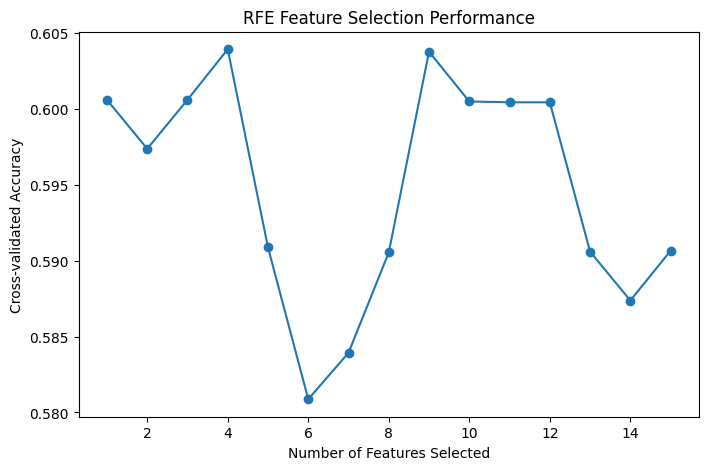

In [15]:
plt.figure(figsize=(8,5))
plt.plot(feature_counts, scores, marker='o')
plt.xlabel("Number of Features Selected")
plt.ylabel("Cross-validated Accuracy")
plt.title("RFE Feature Selection Performance")
plt.show()

### 4. Chi-Square Test

In [16]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

chi2_selector = SelectKBest(chi2, k=best_k)  # use RFE's best_k for consistency
chi2_selector.fit(X_scaled, y)

chi2_features = X.columns[chi2_selector.get_support()]
print("Chi-Square Selected Features:", list(chi2_features))

Chi-Square Selected Features: ['PC1', 'PC2', 'PC5', 'PC11']


### 5. Final Feature Selection

* Take union of RFE, Chi-Square, and top RF/XGB features

In [18]:
top_rf_features = list(rf_importances.head(best_k).index)
top_xgb_features = list(xgb_importances.head(best_k).index)

final_features = list(set(selected_rfe) | set(chi2_features) | set(top_rf_features) | set(top_xgb_features))
print("Final Selected Features:", final_features)

Final Selected Features: ['PC13', 'PC5', 'PC9', 'PC2', 'PC12', 'PC11', 'PC15', 'PC1']


* Reduced dataset

In [19]:
df_selected = df[final_features + ['HeartDisease']]
df_selected.head()

,PC13,PC5,PC9,PC2,PC12,PC11,PC15,PC1,HeartDisease
0,0.174570,2.767598,-0.012057,2.262340,0.723671,0.567220,0.386863,0.684512,0
1,-0.340249,0.017665,-0.204954,1.260364,0.444649,-0.771801,-0.856000,3.570333,2
2,-0.313430,-0.740147,-1.090397,-0.713093,-0.406428,0.148344,-0.251198,3.402447,1
3,1.884434,0.317091,-0.740746,0.220787,0.964626,0.203725,-0.828009,-1.651317,0
4,0.631125,1.199871,0.087860,-0.457629,-1.421694,0.696152,0.302566,-2.501824,0


### 6. Feature importance ranking visualization

In [24]:
# Normalize importances to 0-1 scale for fair comparison
rf_norm = rf_importances / rf_importances.max()
xgb_norm = xgb_importances / xgb_importances.max()

# Create series for RFE and Chi-Square selections
rfe_norm = pd.Series(0, index=X.columns)
rfe_norm[selected_rfe] = 1

chi2_norm = pd.Series(0, index=X.columns)
chi2_norm[chi2_features] = 1

# Combine all scores into a single DataFrame
combined_df = pd.DataFrame({
    'RandomForest': rf_norm,
    'XGBoost': xgb_norm,
    'RFE': rfe_norm,
    'ChiSquare': chi2_norm
})

combined_df['OverallImportance'] = combined_df.sum(axis=1)
combined_df = combined_df.sort_values('OverallImportance', ascending=False)

combined_df.head()


,RandomForest,XGBoost,RFE,ChiSquare,OverallImportance
PC1,1.000000,1.000000,1,1,4.000000
PC11,0.261183,0.297062,1,1,2.558245
PC2,0.274458,0.314052,0,1,1.588510
PC15,0.259035,0.250978,1,0,1.510013
PC12,0.226859,0.268497,1,0,1.495356


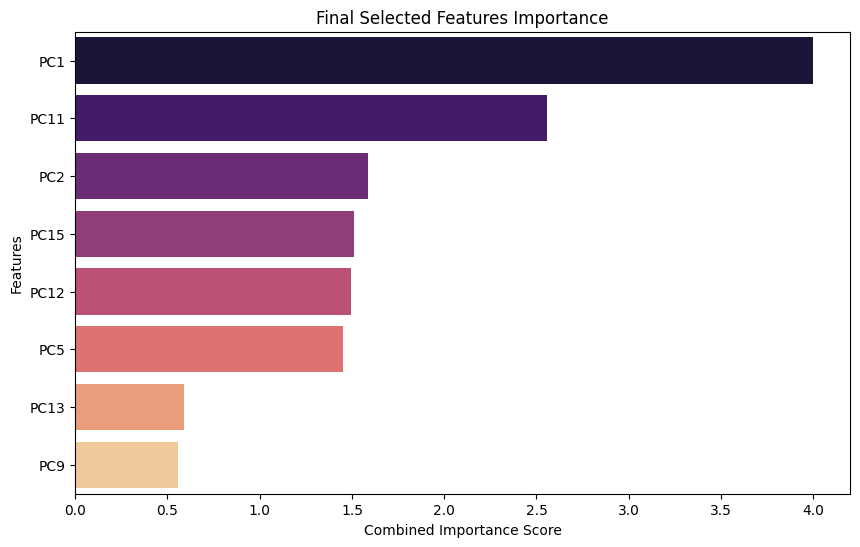

In [35]:

plt.figure(figsize=(10,6))
sns.barplot(x=final_importances.values, y=final_importances.index, hue=final_importances.index, palette='magma', legend=False)
plt.title("Final Selected Features Importance")
plt.xlabel("Combined Importance Score")
plt.ylabel("Features")
plt.show()

# End of this file, go to -> 04_supervised_learning.ipynb